# Telco Customer Churn Analysis

**A business analysis (not a prediction model):** who is leaving, what they have in common, how much it costs, and what to do about it.

Run the cells from top to bottom. Each section starts with a short note explaining what we are doing and why.

## Section 1 - The business problem

A telecom company is losing customers ("churn"). Every customer who leaves is lost monthly revenue, and winning a new customer costs far more than keeping one.

**Questions this analysis answers:**
1. How many customers are leaving (the overall churn rate)?
2. WHICH customers leave most (contract, tenure, internet type, payment method)?
3. Can we describe the highest-risk customers as clear personas?
4. Which factors are most strongly *associated* with leaving?
5. How much money is walking out the door, and what could we save by keeping some of them?

## Setup

Load our tools and locate the data/ and outputs/ folders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make charts look clean and consistent
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Find the data/ and outputs/ folders whether you launch Jupyter from the
# project root or from inside the notebooks/ folder.
if os.path.exists("../data"):
    DATA_DIR, OUT_DIR = "../data", "../outputs"
else:
    DATA_DIR, OUT_DIR = "data", "outputs"

os.makedirs(OUT_DIR, exist_ok=True)   # make sure charts have a place to save
print("Reading data from:", DATA_DIR)
print("Saving charts to: ", OUT_DIR)

Reading data from: ../data
Saving charts to:  ../outputs


## Section 2 - Load and inspect the data

Always look at the data before analysing it: its size, columns, and first rows.

In [2]:
# Load the dataset (the CSV must be inside the data/ folder)
df = pd.read_csv(f"{DATA_DIR}/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Rows and columns:", df.shape)   # how big is the data?
df.head()                              # peek at the first 5 rows

Rows and columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()   # column names, data types, and non-empty counts

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Section 3 - Clean the data

`TotalCharges` is secretly text because 11 rows are blank. We fix the type, handle those blanks honestly, drop the useless ID column, and check for duplicate and missing values.

In [4]:
# TotalCharges came in as text because 11 rows are blank spaces.
# Convert it to numbers; blanks become NaN ("missing").
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing TotalCharges after conversion:", df["TotalCharges"].isna().sum())

Missing TotalCharges after conversion: 11


In [5]:
# Those 11 are brand-new customers (tenure = 0) who have not been billed a
# total yet, so 0 is the honest value.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# customerID is a random ID, useless for analysis -> drop it.
df = df.drop(columns=["customerID"])

# Sanity checks.
# Heads-up: once the unique ID is gone, a handful of rows look identical
# (same plan + demographics). With ~7,000 customers and many categorical
# fields that is expected; they are plausibly different people, so we KEEP
# them rather than delete real customers.
print("Identical-looking rows (kept):", df.duplicated().sum())
print("Missing values left:", df.isna().sum().sum())

Identical-looking rows (kept): 22
Missing values left: 0


In [6]:
# A 1/0 version of Churn so we can AVERAGE it to get churn RATES.
# (mean of a 0/1 column = proportion of 1s = the churn rate)
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)

## Section 4 - Overall churn rate

The headline number. Everything else is compared against this.

Overall churn rate: 26.5%


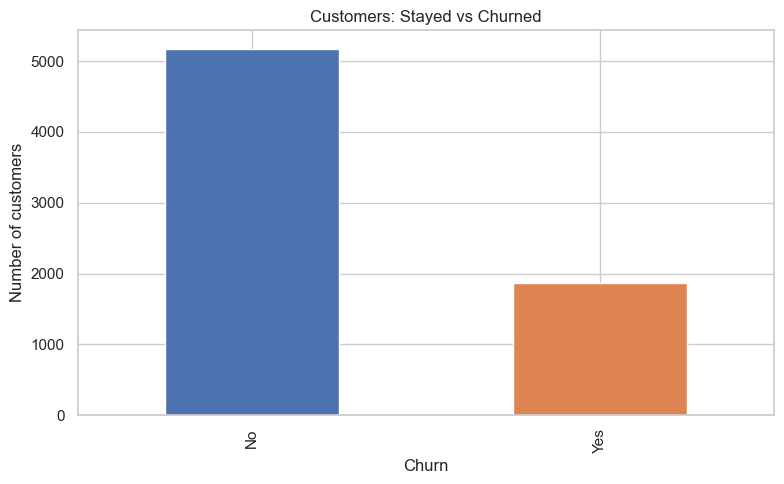

In [7]:
churn_rate = df["ChurnFlag"].mean()
print(f"Overall churn rate: {churn_rate:.1%}")

ax = df["Churn"].value_counts().plot(kind="bar", color=["#4c72b0", "#dd8452"])
ax.set_title("Customers: Stayed vs Churned")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_overall_churn.png", dpi=120)
plt.show()

## Section 5 - Churn by segment

The core of the analysis. For each customer group we ask: do they leave more than the company average (about 26.5%)? We reuse one helper function so the code stays short.

In [8]:
def plot_churn_rate(column, filename, title=None):
    # Show churn RATE (%) for each category in a column, highest first.
    rates = df.groupby(column)["ChurnFlag"].mean().sort_values(ascending=False) * 100
    ax = rates.plot(kind="bar", color="#dd8452")
    ax.set_title(title or f"Churn rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Churn rate (%)")
    for i, v in enumerate(rates):            # write the % on top of each bar
        ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{filename}", dpi=120)
    plt.show()
    return rates

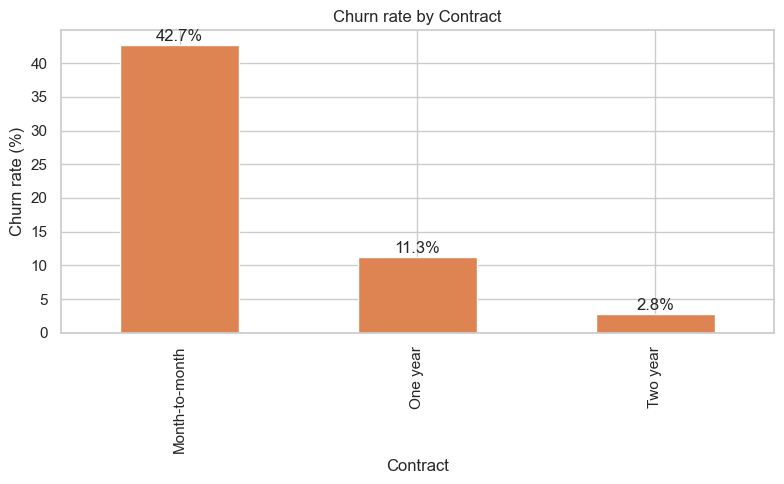

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

In [9]:
plot_churn_rate("Contract", "02_churn_by_contract.png")

**Insight:** Month-to-month customers churn ~15x more than two-year-contract customers (about 42.7% vs 2.8%). This is the biggest single lever.

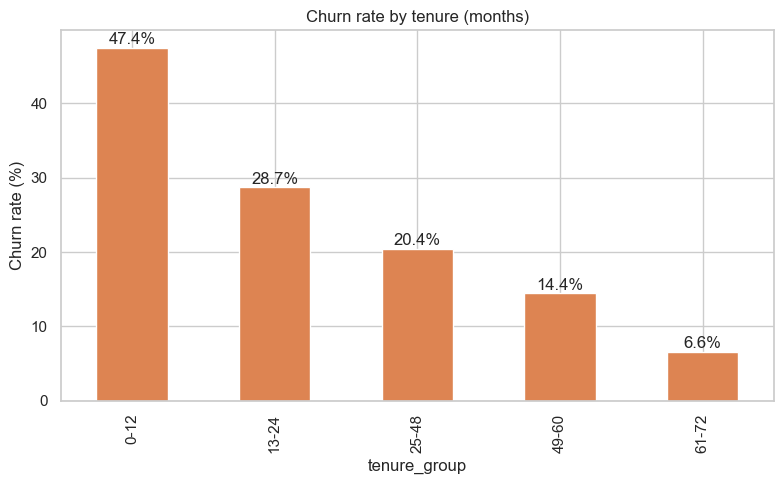

tenure_group
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-60    14.423077
61-72     6.609808
Name: ChurnFlag, dtype: float64

In [10]:
# Group raw tenure (months) into readable buckets
df["tenure_group"] = pd.cut(df["tenure"],
                            bins=[0, 12, 24, 48, 60, 72],
                            labels=["0-12", "13-24", "25-48", "49-60", "61-72"],
                            include_lowest=True)
plot_churn_rate("tenure_group", "03_churn_by_tenure.png", "Churn rate by tenure (months)")

**Insight:** The danger zone is the first year, where churn is highest. Retention effort pays off most early in a customer's life.

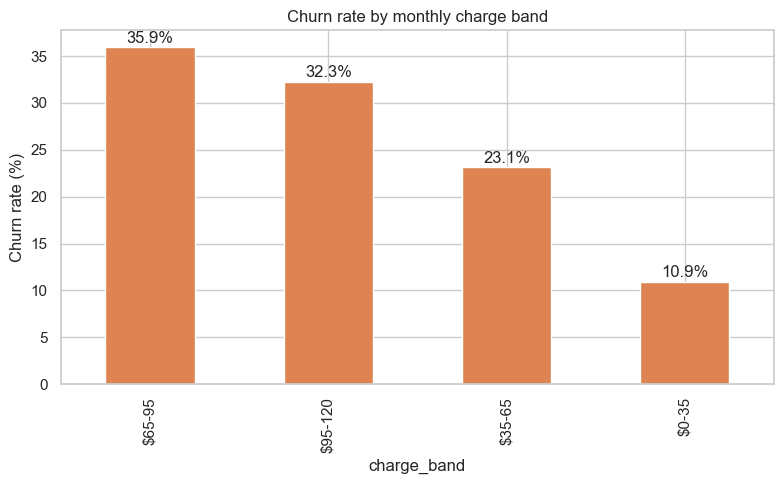

charge_band
$65-95     35.944700
$95-120    32.277992
$35-65     23.136977
$0-35      10.893372
Name: ChurnFlag, dtype: float64

In [11]:
df["charge_band"] = pd.cut(df["MonthlyCharges"],
                           bins=[0, 35, 65, 95, 120],
                           labels=["$0-35", "$35-65", "$65-95", "$95-120"])
plot_churn_rate("charge_band", "04_churn_by_charges.png", "Churn rate by monthly charge band")

**Insight:** Churn rises with the monthly bill. Higher-paying customers feel the price more and leave more.

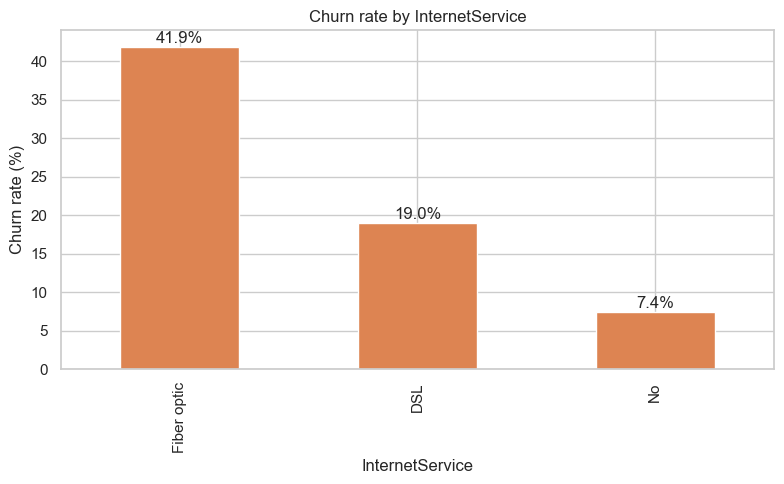

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: ChurnFlag, dtype: float64

In [12]:
plot_churn_rate("InternetService", "05_churn_by_internet.png")

**Insight:** Fiber optic customers churn more than double DSL customers (about 42% vs 19%). Worth investigating fiber price or service quality.

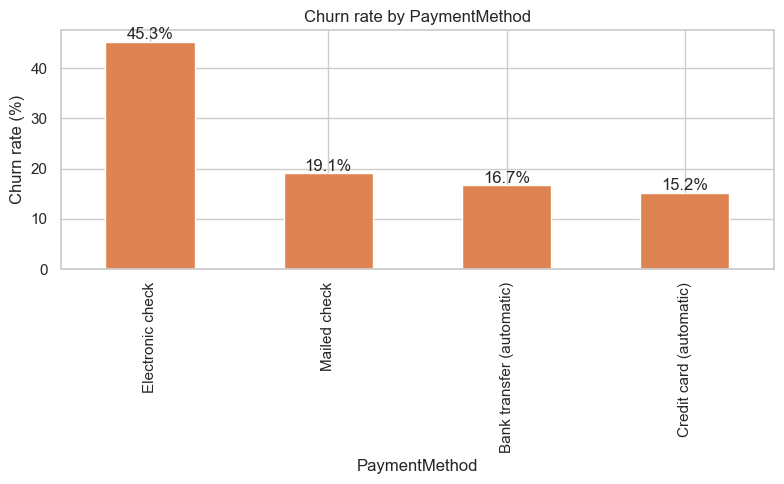

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: ChurnFlag, dtype: float64

In [13]:
plot_churn_rate("PaymentMethod", "06_churn_by_payment.png")

**Insight:** Electronic-check users churn about 3x auto-pay users (about 45% vs 15-17%). Nudging them to auto-pay could help.

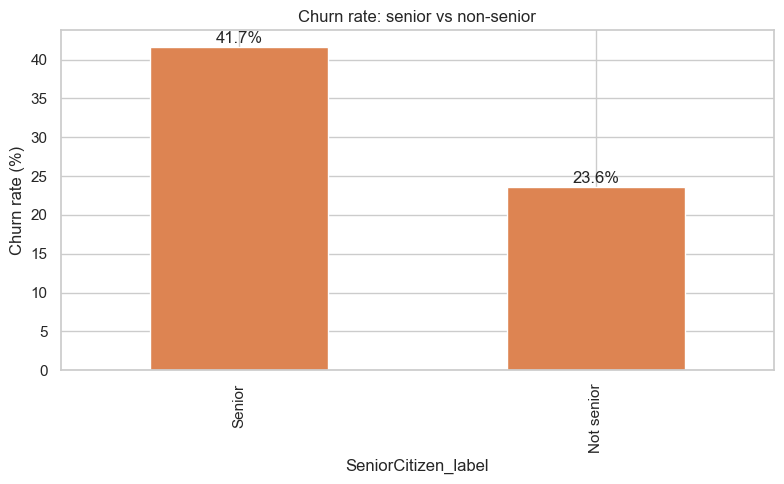

SeniorCitizen_label
Senior        41.681261
Not senior    23.606168
Name: ChurnFlag, dtype: float64

In [14]:
# Senior is stored as 0/1 -> turn it into readable labels
df["SeniorCitizen_label"] = df["SeniorCitizen"].map({0: "Not senior", 1: "Senior"})
plot_churn_rate("SeniorCitizen_label", "07_churn_by_senior.png", "Churn rate: senior vs non-senior")

**Insight:** Seniors churn nearly 2x non-seniors (about 42% vs 24%). They may need simpler plans or better support.

## Section 6 - High-risk personas

Combine the worst factors to find the most dangerous customer. This is what a business team can actually act on.

In [15]:
# The "perfect storm": month-to-month + fiber optic + electronic check
high_risk = df[(df["Contract"] == "Month-to-month") &
               (df["InternetService"] == "Fiber optic") &
               (df["PaymentMethod"] == "Electronic check")]

print("Segment size:", len(high_risk), "customers")
print(f"Segment churn rate: {high_risk['ChurnFlag'].mean():.1%}")

Segment size: 1307 customers
Segment churn rate: 60.4%


**Persona A - "The Flight Risk" (top priority):** month-to-month + fiber optic + electronic check. This exact segment is 1,307 customers and churns 60.4% - more than double the company average, and the single biggest opportunity.

**Persona B - "The Pricey Newcomer":** high monthly bill ($95+), short tenure, no add-on services. Pays a lot, feels little value, leaves fast.

**Persona C - "The Unsupported Senior":** senior, month-to-month, no tech support. Churns well above average and likely needs more help.

## Section 7 - Factors associated with churn (secondary)

This is NOT a prediction project. We fit ONE simple model for a single purpose: to rank which factors line up most strongly with churn. Read the caution after the chart.

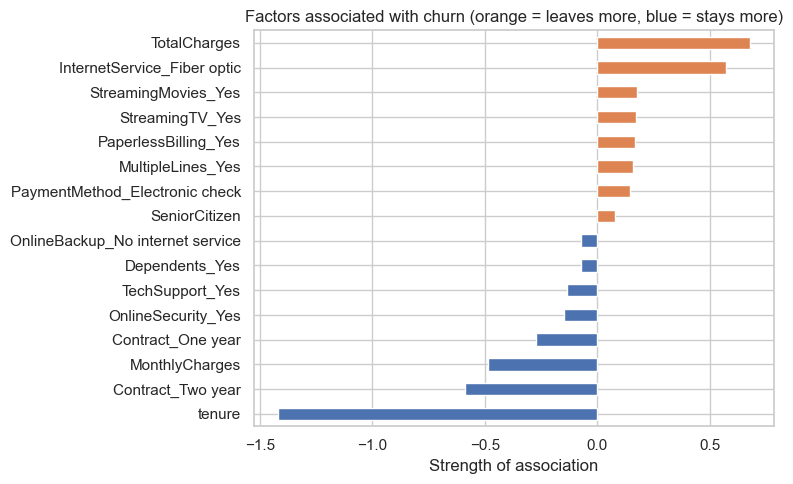

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Turn text columns into 0/1 columns the model can read.
# Drop the helper/label columns we made so they do not leak the answer.
model_df = pd.get_dummies(
    df.drop(columns=["Churn", "tenure_group", "charge_band", "SeniorCitizen_label"]),
    drop_first=True)

X = model_df.drop(columns=["ChurnFlag"])   # the factors
y = model_df["ChurnFlag"]                  # 1 = churned

X_scaled = StandardScaler().fit_transform(X)   # put factors on the same scale

lr = LogisticRegression(max_iter=1000)
lr.fit(X_scaled, y)

# Bigger positive = more associated with LEAVING; negative = more with STAYING.
importance = pd.Series(lr.coef_[0], index=X.columns).sort_values()

top = pd.concat([importance.head(8), importance.tail(8)])
colors = (top > 0).map({True: "#dd8452", False: "#4c72b0"})
ax = top.plot(kind="barh", color=colors)
ax.set_title("Factors associated with churn (orange = leaves more, blue = stays more)")
ax.set_xlabel("Strength of association")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/08_churn_drivers.png", dpi=120)
plt.show()

**What you will typically see:** short tenure, month-to-month contracts, fiber optic, and electronic-check payment are most associated with *leaving*; two-year contracts, long tenure, and support add-ons are most associated with *staying*.

> **Correlation does NOT equal causation.** These factors are *associated* with churn, they do not prove a cause. Treat this as "where to look," not "the reason why."

## Section 8 - Revenue at risk (the money story)

Translate churn into dollars. Numbers get noticed; money gets meetings.

In [17]:
churned = df[df["Churn"] == "Yes"]

monthly_lost = churned["MonthlyCharges"].sum()   # revenue leaving each month
annual_lost = monthly_lost * 12

print(f"Customers churned:       {len(churned):,}")
print(f"Monthly revenue lost:    ${monthly_lost:,.0f}")
print(f"Annualized revenue lost: ${annual_lost:,.0f}")

# Rough rupee view (about 83 INR per USD)
print(f"Annualized (approx INR): Rs {annual_lost * 83:,.0f}")

Customers churned:       1,869
Monthly revenue lost:    $139,131
Annualized revenue lost: $1,669,570
Annualized (approx INR): Rs 138,574,327


In [18]:
# What if a retention offer keeps just 10% of month-to-month churners?
m2m_churners = df[(df["Contract"] == "Month-to-month") & (df["Churn"] == "Yes")]
saved_customers = int(len(m2m_churners) * 0.10)
annual_saved = m2m_churners["MonthlyCharges"].mean() * saved_customers * 12

print(f"Keeping 10% of month-to-month churners = {saved_customers} customers")
print(f"Revenue saved per year: ${annual_saved:,.0f}  (approx Rs {annual_saved * 83:,.0f})")

Keeping 10% of month-to-month churners = 165 customers
Revenue saved per year: $144,578  (approx Rs 12,000,008)


**How to read it:** even a modest 10% rescue of just one high-risk group funds a whole retention program. The dataset is in US dollars; the rupee figures are an approximate conversion.

## Section 9 - Recommendations (prioritized)

1. **Move month-to-month customers onto 1-2 year contracts** (loyalty discount). *Why:* month-to-month churns ~42.7% vs 2.8% on two-year, the biggest lever.
2. **Build a first-90-days onboarding program.** *Why:* the 0-12 month group churns the most.
3. **Nudge electronic-check users to auto-pay** (small switching discount). *Why:* electronic check churns ~45% vs ~15-17% for auto-pay.
4. **Audit fiber pricing and service quality.** *Why:* fiber churns ~42% vs ~19% for DSL.
5. **Bundle tech support / online security** into plans. *Why:* having them is associated with staying.
6. **Targeted save-offers for the "Flight Risk" persona** (month-to-month + fiber + e-check, 60.4% churn).

## Section 10 - Limitations (read honestly)

- **Correlation does not equal causation.** Everything here shows *association*, not proven cause. A controlled A/B test on a retention offer would be needed to prove cause.
- **Imbalanced data.** Only about 26.5% of customers churned, so "Yes" is the minority. A model that always predicts "stays" would look ~73% accurate yet be useless, which is exactly why this project focuses on rates and business insight, not model accuracy.
- **Single snapshot in time.** No dates or trend, so we cannot see churn rising or falling.
- **Missing context.** No competitor pricing, complaints, or marketing data, all of which affect churn in the real world.

## Done

Charts are saved in the outputs/ folder. See the project README.md for the recruiter-facing summary, key findings, and how to run this.